# 04. Final Experiment (Log Return)

Bu notebook'ta **Log Return** hedef değişkeni üzerinde **Zero Return**, **Previous Return**, **Linear Regression (Lags: 1, 2, 3, 5, 10)**, **LSTM** ve **GRU** modelleri test edilmektedir.

### Metodoloji Kuralları:
1. **Early Stopping & Checkpointing:** `import copy; best_weights = copy.deepcopy(model.state_dict())` kullanılarak en iyi validasyon checkpoint'i eksiksiz geri yüklenir.
2. **Kesin İndeks Sınırları:** Train (%70), Validation (%15) ve Test (%15) kümeleri arasında hiçbir satır çakışması yoktur. Test dönemi tam olarak `log_ret.iloc[val_end:]` aralığına karşılık gelir.
3. **Hizalanmış Test Değerlendirmesi:** Tüm modellerin test metrikleri tam olarak aynı test timestamp'leri ve aynı $N$ örnek sayısı üzerinde hesaplanır.
4. **Öğrenme Eğrileri (Learning Curves):** LSTM ve GRU modellerinin train ve validation loss geçmişleri kaydedilip görselleştirilir.
5. **Price-Space Evaluation:** Tahmin edilen log return'ler $Predicted\_Close_t = Actual\_Close_{t-1} \cdot \exp(\hat{y}_t)$ formülüyle one-step-ahead fiyat tahminine dönüştürülüp Naive Price Baseline ile karşılaştırılır.

In [1]:
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.utils.data as data
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Model ve eğitim hiperparametreleri
LOOKBACK = 20
HIDDEN_SIZE = 32
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 100
PATIENCE = 5

## 1. Veri Yükleme ve Target Hazırlığı

AMZN Close serisinden günlük log return ($r_t = \ln(Close_t / Close_{t-1})$) hesaplanır ve ilk NaN satırı temizlenir.

In [2]:
data_path = 'data/amzn_stock.csv' if os.path.exists('data/amzn_stock.csv') else '../data/amzn_stock.csv'
df = pd.read_csv(data_path, index_col="Date", parse_dates=True)
close = df['Close']
log_ret = np.log(close / close.shift(1)).dropna()

N_total = len(log_ret)
train_end = int(N_total * 0.70)
val_end = int(N_total * 0.85)

train_data = log_ret.iloc[:train_end]
val_data = log_ret.iloc[train_end:val_end]
test_data = log_ret.iloc[val_end:]

N_train = len(train_data)
N_val = len(val_data)
N_test = len(test_data)

print(f"Toplam Veri: {N_total}")
print(f"Train Kümesi: {N_train} satır ({train_data.index[0].date()} - {train_data.index[-1].date()})")
print(f"Validation Kümesi: {N_val} satır ({val_data.index[0].date()} - {val_data.index[-1].date()})")
print(f"Test Kümesi (N): {N_test} satır ({test_data.index[0].date()} - {test_data.index[-1].date()})")

Toplam Veri: 4023
Train Kümesi: 2816 satır (2010-01-05 - 2021-03-12)
Validation Kümesi: 603 satır (2021-03-15 - 2023-08-04)
Test Kümesi (N): 604 satır (2023-08-07 - 2025-12-31)


## 2. Baselines (Zero Return, Previous Return, Linear Regression)

Bütün baseline modeller tam olarak aynı test indeksleri (`test_data.index`, $N = 604$) üzerinde tahmin üretir.

In [3]:
# 1. Zero Return: Her gün için tahmin = 0
zero_val_pred = np.zeros(N_val)
zero_test_pred = np.zeros(N_test)

# 2. Previous Return: prediction_t = actual_{t-1}
prev_val_pred = log_ret.shift(1).iloc[train_end:val_end].values
prev_test_pred = log_ret.shift(1).iloc[val_end:].values

# 3. Linear Regression (Lags: 1, 2, 3, 5, 10)
lags = [1, 2, 3, 5, 10]
df_lags = pd.DataFrame(index=log_ret.index)
for l in lags:
    df_lags[f'lag_{l}'] = log_ret.shift(l)

# Train, val, test sınırları kesin olarak ayrıdır
X_train_lr = df_lags.iloc[max(lags):train_end]
y_train_lr = log_ret.iloc[max(lags):train_end]

X_val_lr = df_lags.iloc[train_end:val_end]
y_val_lr = log_ret.iloc[train_end:val_end]

X_test_lr = df_lags.iloc[val_end:]
y_test_lr = log_ret.iloc[val_end:]

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

lr_val_pred = lr_model.predict(X_val_lr)
lr_test_pred = lr_model.predict(X_test_lr)

print(f"Baseline test tahmin boyutları doğrulandı: Zero={len(zero_test_pred)}, Prev={len(prev_test_pred)}, LR={len(lr_test_pred)}")

Baseline test tahmin boyutları doğrulandı: Zero=604, Prev=604, LR=604


## 3. Deep Learning Veri Hazırlığı (Sliding Window & DataLoader)

In [4]:
def create_sequences(data_array, lookback):
    X, y = [], []
    for i in range(len(data_array) - lookback):
        X.append(data_array[i:i + lookback])
        y.append(data_array[i + lookback])
    return np.array(X), np.array(y)

X_train_dl, y_train_dl = create_sequences(train_data.values, LOOKBACK)
val_input = log_ret.iloc[train_end - LOOKBACK : val_end].values
X_val_dl, y_val_dl = create_sequences(val_input, LOOKBACK)
test_input = log_ret.iloc[val_end - LOOKBACK :].values
X_test_dl, y_test_dl = create_sequences(test_input, LOOKBACK)

assert len(y_test_dl) == N_test, f"Test uzunluğu eşleşmiyor: {len(y_test_dl)} vs {N_test}"
assert len(y_val_dl) == N_val, f"Validation uzunluğu eşleşmiyor: {len(y_val_dl)} vs {N_val}"

torch.manual_seed(42)
np.random.seed(42)

train_dataset = data.TensorDataset(
    torch.tensor(X_train_dl, dtype=torch.float32).unsqueeze(-1),
    torch.tensor(y_train_dl, dtype=torch.float32)
)
train_loader = data.DataLoader(train_dataset, batch_size=32, shuffle=True)

val_X_t = torch.tensor(X_val_dl, dtype=torch.float32).unsqueeze(-1)
val_y_t = torch.tensor(y_val_dl, dtype=torch.float32)
test_X_t = torch.tensor(X_test_dl, dtype=torch.float32).unsqueeze(-1)

print("Tensor boyutları:")
print(f"Train: X={X_train_dl.shape}, y={y_train_dl.shape}")
print(f"Val:   X={X_val_dl.shape}, y={y_val_dl.shape}")
print(f"Test:  X={X_test_dl.shape}, y={y_test_dl.shape}")

Tensor boyutları:
Train: X=(2796, 20), y=(2796,)
Val:   X=(603, 20), y=(603,)
Test:  X=(604, 20), y=(604,)


## 4. Model Mimarisi ve Deepcopy Destekli Early Stopping Eğitimi

In [5]:
class DLModel(nn.Module):
    def __init__(self, mtype='LSTM', input_size=1, hidden_size=32, num_layers=2):
        super().__init__()
        if mtype == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

def train_dl(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    best_val_loss = float('inf')
    best_weights = None
    p_counter = 0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for bx, by in train_loader:
            optimizer.zero_grad()
            pred = model(bx)
            loss = criterion(pred, by)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(bx)
            
        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)
        
        model.eval()
        with torch.no_grad():
            val_pred = model(val_X_t)
            val_loss = criterion(val_pred, val_y_t).item()
            val_losses.append(val_loss)
            
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            p_counter = 0
        else:
            p_counter += 1
            if p_counter >= PATIENCE:
                break
                
    model.load_state_dict(best_weights)
    return model, train_losses, val_losses

torch.manual_seed(42)
lstm_model, lstm_train_losses, lstm_val_losses = train_dl(DLModel('LSTM', input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS))

torch.manual_seed(42)
gru_model, gru_train_losses, gru_val_losses = train_dl(DLModel('GRU', input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS))

print("LSTM ve GRU eğitimleri tamamlandı.")

LSTM ve GRU eğitimleri tamamlandı.


## 5. Learning Curves (Eğitim ve Doğrulama Kayıpları)

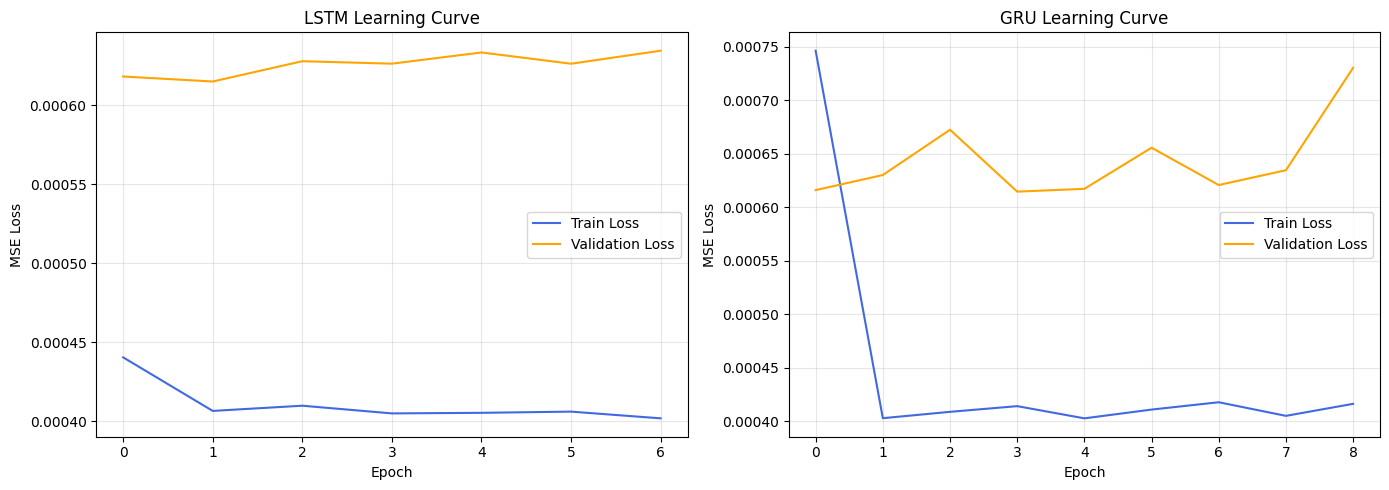

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_train_losses, label='Train Loss', color='royalblue')
axes[0].plot(lstm_val_losses, label='Validation Loss', color='orange')
axes[0].set_title('LSTM Learning Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(gru_train_losses, label='Train Loss', color='royalblue')
axes[1].plot(gru_val_losses, label='Validation Loss', color='orange')
axes[1].set_title('GRU Learning Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Değerlendirme Tablosu (Log Return Metrikleri)

In [7]:
with torch.no_grad():
    lstm_val_pred = lstm_model(val_X_t).numpy()
    lstm_test_pred = lstm_model(test_X_t).numpy()
    gru_val_pred = gru_model(val_X_t).numpy()
    gru_test_pred = gru_model(test_X_t).numpy()

def calc_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    da = np.mean(np.sign(actual) == np.sign(pred))
    return rmse, mae, da

models = {
    'Zero Return': (zero_val_pred, zero_test_pred),
    'Previous Return': (prev_val_pred, prev_test_pred),
    'Linear Regression': (lr_val_pred, lr_test_pred),
    'LSTM': (lstm_val_pred, lstm_test_pred),
    'GRU': (gru_val_pred, gru_test_pred),
}

y_test_actual = test_data.values
y_val_actual = val_data.values

results = []
for name, (vp, tp) in models.items():
    v_rmse = np.sqrt(mean_squared_error(y_val_actual, vp))
    t_rmse, t_mae, t_da = calc_metrics(y_test_actual, tp)
    results.append({
        'Model': name,
        'N': N_test,
        'Validation RMSE': v_rmse,
        'Test RMSE': t_rmse,
        'MAE': t_mae,
        'Direction Accuracy': t_da if name != 'Zero Return' else np.nan
    })

results_df = pd.DataFrame(results)
formatted_df = results_df.copy()
formatted_df['Validation RMSE'] = formatted_df['Validation RMSE'].map(lambda x: f'{x:.5f}')
formatted_df['Test RMSE'] = formatted_df['Test RMSE'].map(lambda x: f'{x:.5f}')
formatted_df['MAE'] = formatted_df['MAE'].map(lambda x: f'{x:.5f}')
formatted_df['Direction Accuracy'] = formatted_df['Direction Accuracy'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
display(formatted_df)

,Model,N,Validation RMSE,Test RMSE,MAE,Direction Accuracy
0,Zero Return,604,0.02478,0.01945,0.01399,N/A
1,Previous Return,604,0.03494,0.02803,0.02049,0.4868
2,Linear Regression,604,0.02486,0.01940,0.01396,0.5199
3,LSTM,604,0.02480,0.01951,0.01406,0.4702
4,GRU,604,0.02479,0.01947,0.01402,0.4785


## 7. Price-Space Evaluation (Gerçek Fiyat Karşılaştırması)

One-step-ahead fiyat tahmini formülü: $Predicted\_Close_t = Actual\_Close_{t-1} \cdot \exp(\hat{r}_t)$

In [8]:
test_actual_close_prev = close.shift(1).loc[test_data.index].values
actual_test_close = close.loc[test_data.index].values

lstm_price_pred = test_actual_close_prev * np.exp(lstm_test_pred)
gru_price_pred = test_actual_close_prev * np.exp(gru_test_pred)
naive_price_pred = test_actual_close_prev

lstm_price_rmse = np.sqrt(mean_squared_error(actual_test_close, lstm_price_pred))
gru_price_rmse = np.sqrt(mean_squared_error(actual_test_close, gru_price_pred))
naive_price_rmse = np.sqrt(mean_squared_error(actual_test_close, naive_price_pred))

price_results = pd.DataFrame([
    {'Model': 'Naive Price Baseline', 'Price RMSE': f'{naive_price_rmse:.6f}'},
    {'Model': 'LSTM', 'Price RMSE': f'{lstm_price_rmse:.6f}'},
    {'Model': 'GRU', 'Price RMSE': f'{gru_price_rmse:.6f}'}
])
display(price_results)

,Model,Price RMSE
0,Naive Price Baseline,3.726560
1,LSTM,3.736202
2,GRU,3.729627


## 8. Sonuç Özeti

Mevcut AMZN veri seti ve kurgulanan deney kapsamında:
- GRU modeli ($Price\_RMSE = 3.729627$), LSTM modelinden ($Price\_RMSE = 3.736202$) çok az daha iyi performans göstermiştir.
- Ancak deep learning modelleri basit Naive Baseline ($Price\_RMSE = 3.726560$) ve Zero Return ($Test\_RMSE = 0.01945$) üzerinde anlamlı bir prediktif iyileşme sağlamamıştır.
- Basit Linear Regression yön doğruluğunda %51.99 ile en yüksek sonucu vermiştir.